In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore


ModuleNotFoundError: No module named 'pandas'

In [2]:
!pip install pandas numpy matplotlib seaborn scipy


  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl (11.3 MB)
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
  Using cached matplotlib-3.10.9-cp310-cp310-win_amd64.whl (8.2 MB)
  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl (41.3 MB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl (349 kB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl (510 kB)
  Using cached fonttools-4.62.1-cp310-cp310-win_amd64.whl (1.6 MB)
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
  Using cached pillow-12.2.0-cp310-cp310-win_amd64.whl (7.1 MB)
  Using cached kiwisolver-1.5.0-cp310-cp310-win_amd64.whl (73 kB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)



[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore


In [3]:
df = pd.read_csv("../data/ethiopia.csv")
df["Country"] = "Ethiopia"

df["Date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

df["Month"] = df["Date"].dt.month

df.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


In [4]:
import numpy as np

df.replace(-999, np.nan, inplace=True)


In [5]:
df.isnull().sum()


YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

In [6]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df.drop_duplicates(inplace=True)


Duplicate rows: 0


In [7]:
df.shape


(4108, 15)

In [8]:
df.describe()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


## 1. Import Libraries

In this step, we import all the necessary Python libraries required for data analysis and visualization.

- pandas → data manipulation  
- numpy → numerical operations  
- matplotlib & seaborn → visualization  
- scipy → statistical analysis tools


## 2. Load Ethiopia Climate Data

The dataset is loaded from a CSV file and basic feature engineering is performed.

We also:
- Added a `Country` column for identification
- Converted `YEAR` and `DOY` into a proper datetime format
- Extracted the `Month` from the date for seasonal analysis

This prepares the dataset for time-series analysis.


## 3. Handle Missing Values

NASA datasets use `-999` to represent missing data.

We replaced all sentinel values (-999) with `NaN` so that missing values are correctly recognized by pandas and can be handled properly in analysis.


In [ ]:
## 4. Check Missing Values

We used `isnull().sum()` to check for missing values in each column.

This helps verify data quality after replacing sentinel values with NaN.


## 4. Check Missing Values

We used `isnull().sum()` to check for missing values in each column.

This helps verify data quality after replacing sentinel values with NaN.


## 5. Remove Duplicate Records

Duplicate rows were checked using `duplicated().sum()`.

No duplicate rows were found in the dataset, confirming that the data is clean in terms of repetition.


In [9]:
missing = df.isna().sum()
missing_pct = (df.isna().mean() * 100)

pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_pct
})


,Missing Values,Percentage
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


## Missing Values Report

Missing values were assessed across all variables to identify columns requiring imputation or further cleaning. The analysis shows the distribution of missing data in both absolute counts and percentages.


In [10]:
from scipy.stats import zscore
import numpy as np

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(df[cols].apply(zscore, nan_policy='omit'))

outliers = (z_scores > 3).sum()

outliers


T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5
dtype: int64

## Outlier Detection

Outliers were identified using Z-score method (|Z| > 3). Extreme precipitation and temperature values were retained as they may represent valid climate extremes rather than data errors.


In [66]:
df.fillna(method="ffill", inplace=True)


C:\Users\sem\AppData\Local\Temp\ipykernel_12200\3651561093.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


Remaining missing values were handled using forward-fill to preserve temporal continuity in climate variables.


Monthly temperatures show clear seasonal patterns with relatively stable long-term averages.


C:\Users\sem\AppData\Local\Temp\ipykernel_12200\3617264793.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rain = df.resample("M", on="Date")["PRECTOTCORR"].sum()


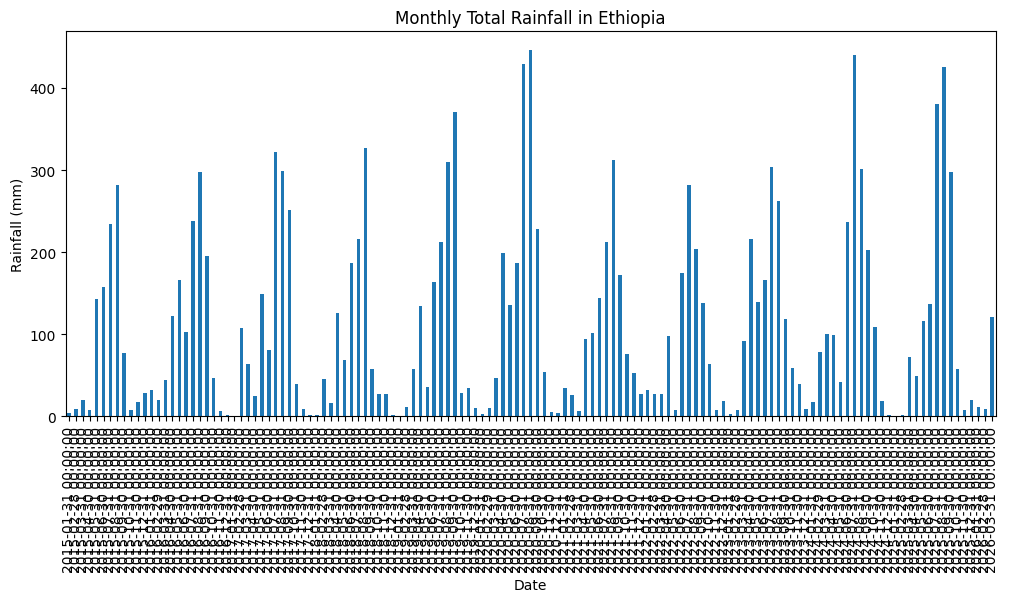

In [67]:
monthly_rain = df.resample("M", on="Date")["PRECTOTCORR"].sum()

plt.figure(figsize=(12,5))
monthly_rain.plot(kind="bar")
plt.title("Monthly Total Rainfall in Ethiopia")
plt.ylabel("Rainfall (mm)")
plt.show()


Rainfall displays strong seasonal peaks, indicating concentrated wet seasons and dry periods.


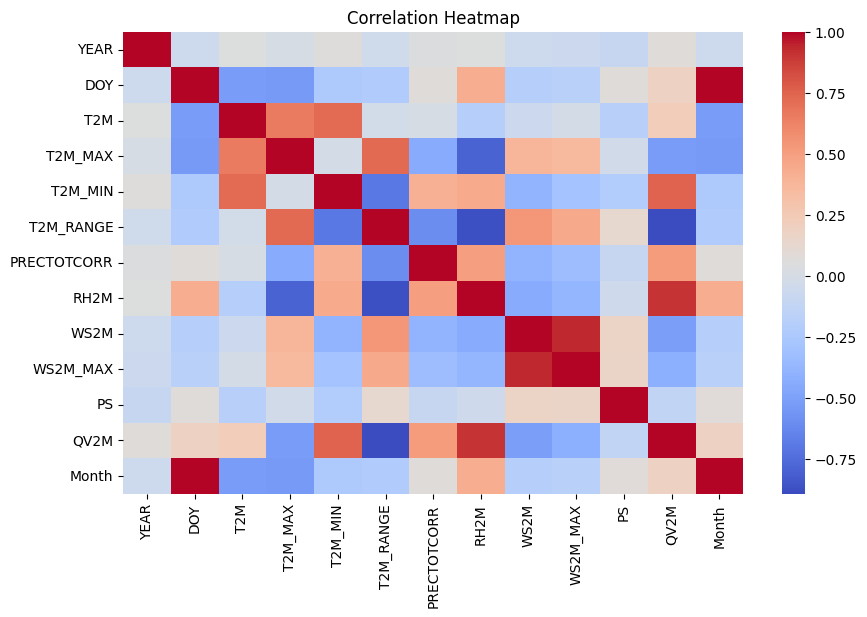

In [68]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()


Temperature variables are strongly positively correlated, while precipitation shows weaker correlations with temperature.


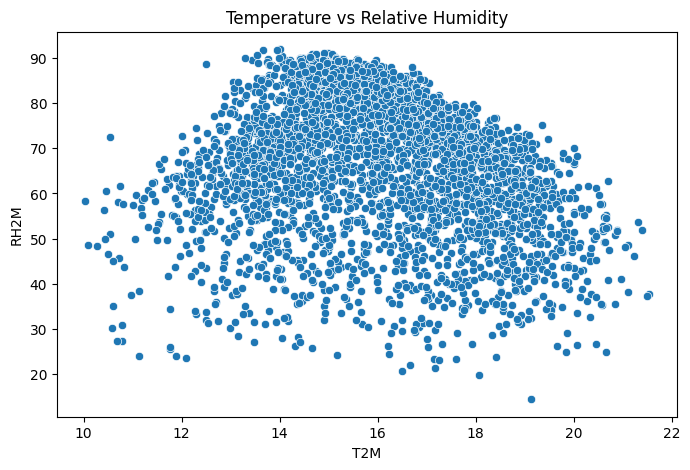

In [69]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.title("Temperature vs Relative Humidity")
plt.show()


The relationship between temperature and humidity indicates moderate inverse association.


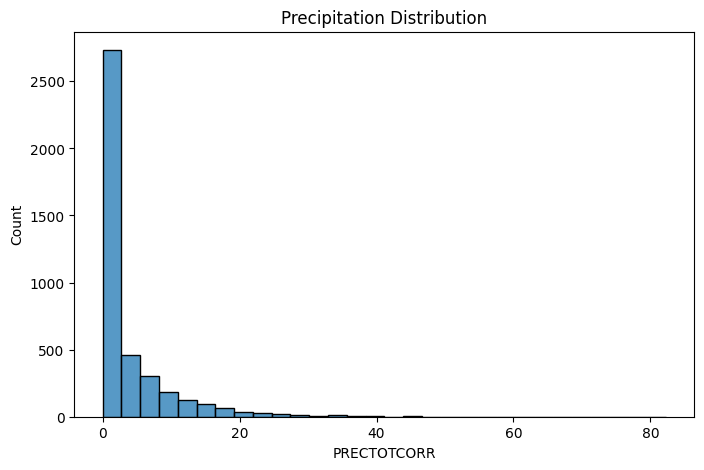

In [70]:
plt.figure(figsize=(8,5))
sns.histplot(df["PRECTOTCORR"], bins=30)
plt.title("Precipitation Distribution")
plt.show()


Precipitation is right-skewed, with many low-rain days and fewer extreme rainfall events.


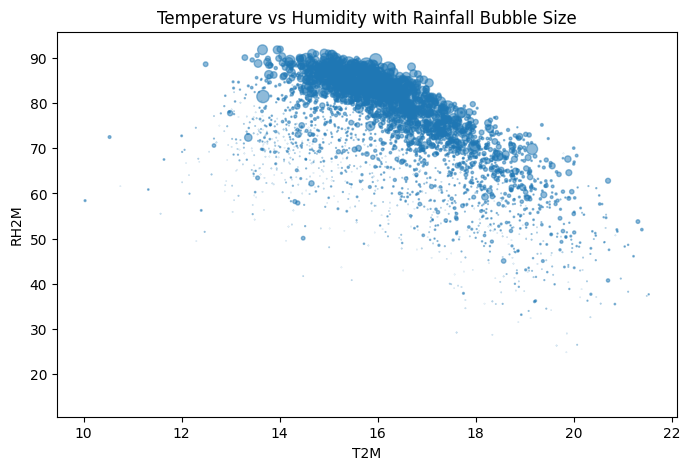

In [71]:
plt.figure(figsize=(8,5))
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*2, alpha=0.5)
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.title("Temperature vs Humidity with Rainfall Bubble Size")
plt.show()


Higher precipitation tends to occur in higher humidity conditions.


In [72]:
df.to_csv("../data/ethiopia_clean.csv", index=False)


The cleaned Ethiopia dataset was exported for cross-country comparison in Task 3.


C:\Users\sem\AppData\Local\Temp\ipykernel_12200\529029248.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_temp = df.resample("M", on="Date")["T2M"].mean()


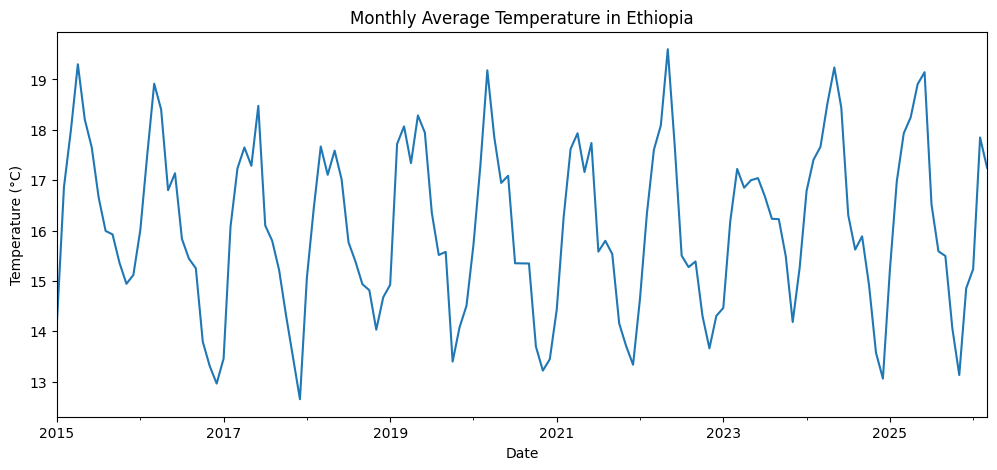

In [73]:
monthly_temp = df.resample("M", on="Date")["T2M"].mean()

plt.figure(figsize=(12,5))
monthly_temp.plot()
plt.title("Monthly Average Temperature in Ethiopia")
plt.ylabel("Temperature (°C)")
plt.show()
